# 06 Model Result Visualization

B팀의 4주차 모델링 결과를 바탕으로 보고서/PPT에 사용할 그래프를 정리합니다.

사용 파일:
- `outputs/kmeans_cluster_summary.csv`
- `outputs/latest_region_risk_ranking.csv`
- `outputs/model_comparison.csv`
- `outputs/feature_importance.csv`
- `outputs/modeling_result_dataset.csv`


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

OUTPUT_DIR = ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150


def comma_axis(ax):
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))


def save_fig(filename):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()


In [2]:
cluster = pd.read_csv(ROOT / "outputs" / "kmeans_cluster_summary.csv", encoding="utf-8-sig")
ranking = pd.read_csv(ROOT / "outputs" / "latest_region_risk_ranking.csv", encoding="utf-8-sig")
comparison = pd.read_csv(ROOT / "outputs" / "model_comparison.csv", encoding="utf-8-sig")
importance = pd.read_csv(ROOT / "outputs" / "feature_importance.csv", encoding="utf-8-sig")
result = pd.read_csv(ROOT / "outputs" / "modeling_result_dataset.csv", encoding="utf-8-sig")

cluster.head()


,kmeans_cluster,sample_count,avg_total_risk_score,avg_resident_risk_index,avg_investor_risk_index,avg_stagnation_score,avg_gap_rate,avg_sale_growth_1m,avg_growth_gap_1m,avg_monthly_ratio,risk_target_rate,warning_rate,risk_rank,cluster_risk_label
0,3,107,0.742676,0.717719,0.767633,0.238318,0.541794,0.081749,0.117370,0.447966,0.925234,0.570093,5,우선점검
1,4,197,0.576213,0.570879,0.581548,0.395685,0.566425,-0.004747,-0.018549,0.436807,0.365482,0.126904,4,신중검토
2,2,284,0.474066,0.471353,0.476778,0.214613,0.448633,0.015454,0.014006,0.392471,0.105634,0.007042,3,관찰
3,0,179,0.451424,0.467058,0.435791,0.210615,0.393081,0.008595,0.007271,0.528368,0.100559,0.000000,2,양호
4,1,108,0.273889,0.289569,0.258210,0.269907,0.394377,-0.069759,-0.133203,0.452403,0.000000,0.000000,1,안정권


## 1. K-Means 군집별 평균 위험 점수

각 K-Means 군집이 평균적으로 어느 정도의 통합 위험 점수를 가지는지 비교합니다.


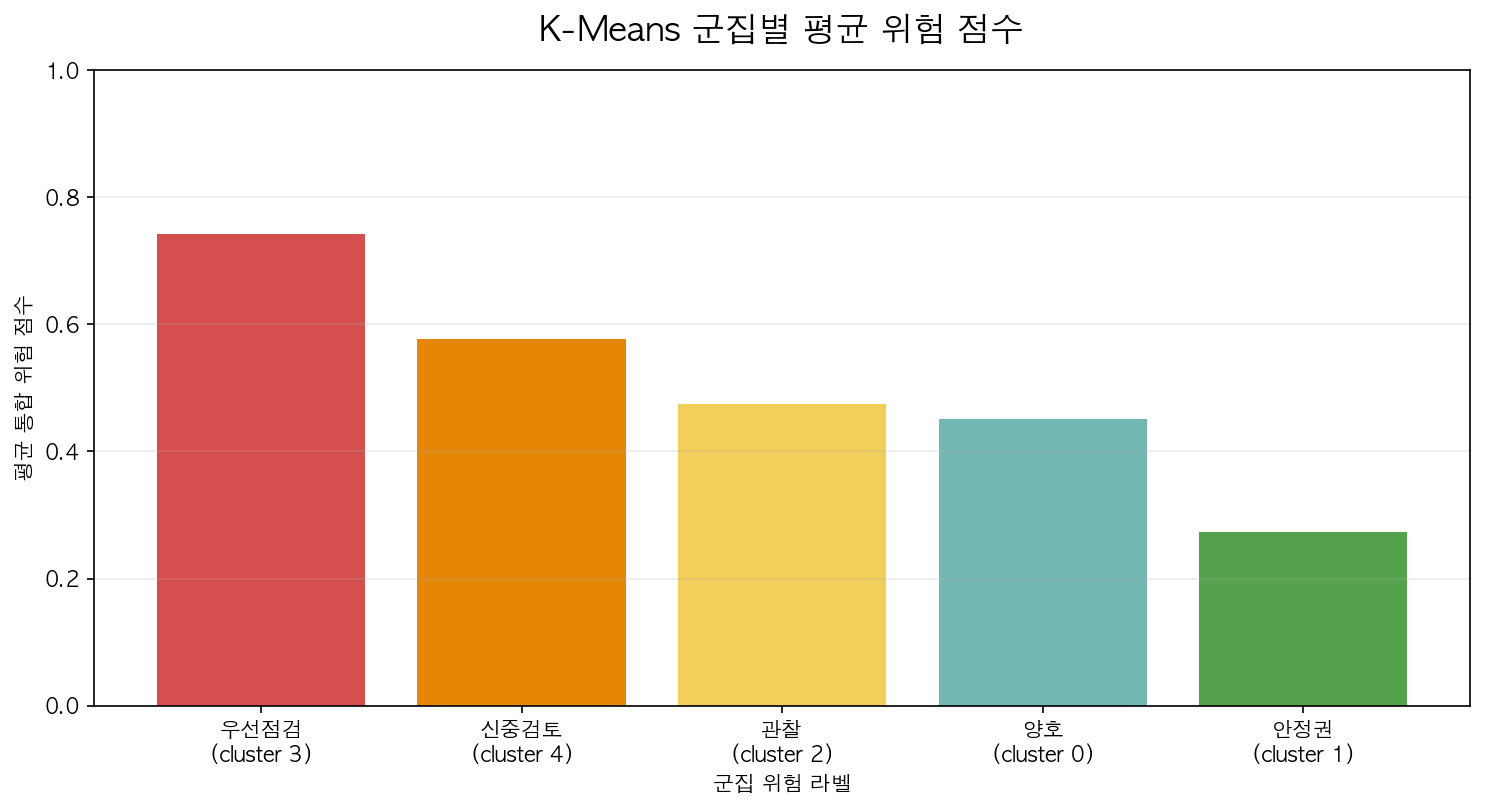

In [3]:
cluster_sorted = cluster.sort_values("risk_rank", ascending=False).copy()
cluster_sorted["cluster_label"] = (
    cluster_sorted["cluster_risk_label"]
    + "\n(cluster "
    + cluster_sorted["kmeans_cluster"].astype(str)
    + ")"
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(
    cluster_sorted["cluster_label"],
    cluster_sorted["avg_total_risk_score"],
    color=["#D64F4F", "#E58606", "#F2CF5B", "#72B7B2", "#54A24B"],
)
ax.set_title("K-Means 군집별 평균 위험 점수", fontsize=16, pad=14)
ax.set_xlabel("군집 위험 라벨")
ax.set_ylabel("평균 통합 위험 점수")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
save_fig("kmeans_avg_risk_score.png")


**해석**
- `우선점검` 군집은 평균 통합 위험 점수가 가장 높게 나타나며, 다른 군집보다 위험 신호가 강하게 나타나는 그룹으로 해석합니다.
- `신중검토`, `관찰`, `양호`, `안정권` 순으로 위험 수준이 낮아지는 구조를 보여주기 때문에, K-Means가 지역·월별 데이터를 위험 수준에 따라 구분했다는 점을 설명할 수 있습니다.
- 발표에서는 이 그래프를 통해 “모델이 단순히 지역명을 나눈 것이 아니라, 위험 지표의 패턴이 비슷한 데이터끼리 군집화했습니다”라고 설명하면 좋습니다.


## 2. K-Means 군집별 샘플 수

각 K-Means 군집에 포함된 지역·월 단위 데이터의 개수를 확인합니다.


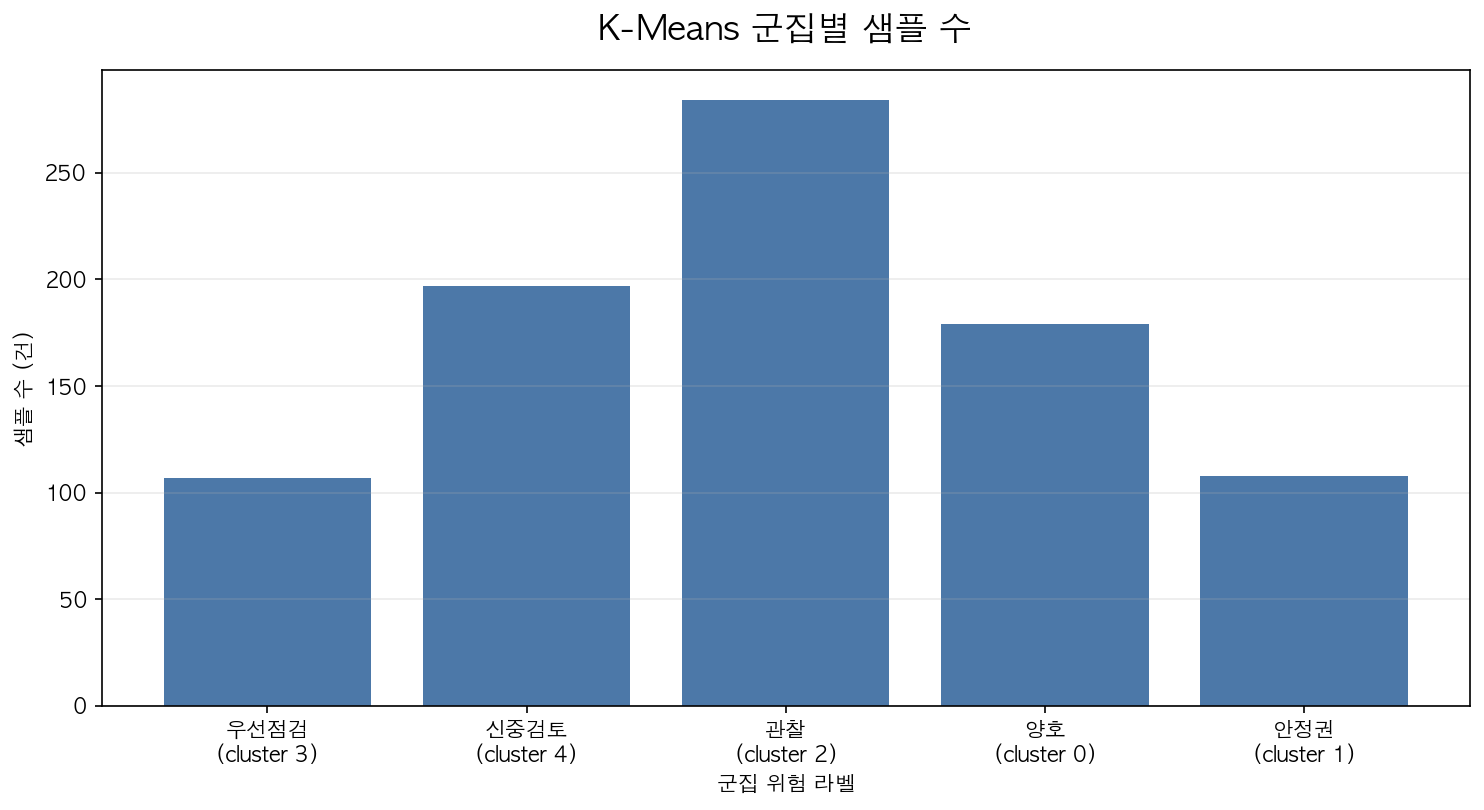

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(cluster_sorted["cluster_label"], cluster_sorted["sample_count"], color="#4C78A8")
ax.set_title("K-Means 군집별 샘플 수", fontsize=16, pad=14)
ax.set_xlabel("군집 위험 라벨")
ax.set_ylabel("샘플 수 (건)")
comma_axis(ax)
ax.grid(axis="y", alpha=0.25)
save_fig("kmeans_cluster_sample_count.png")


**해석**
- `관찰`, `신중검토`, `양호` 군집에 표본이 많이 분포하며, 대부분의 지역·월 데이터는 중간 수준의 위험 구간에 몰려 있음을 확인할 수 있습니다.
- `우선점검` 군집은 표본 수가 상대적으로 적지만 평균 위험 점수가 가장 높기 때문에, 빈도는 낮아도 위험도가 큰 구간으로 해석합니다.
- 이 그래프는 평균 위험 점수 그래프와 함께 사용하면, 각 군집의 위험 수준뿐 아니라 해당 위험 유형이 얼마나 자주 나타나는지도 함께 설명할 수 있습니다.


## 3. 최신 월 기준 지역별 위험 순위 Top 10


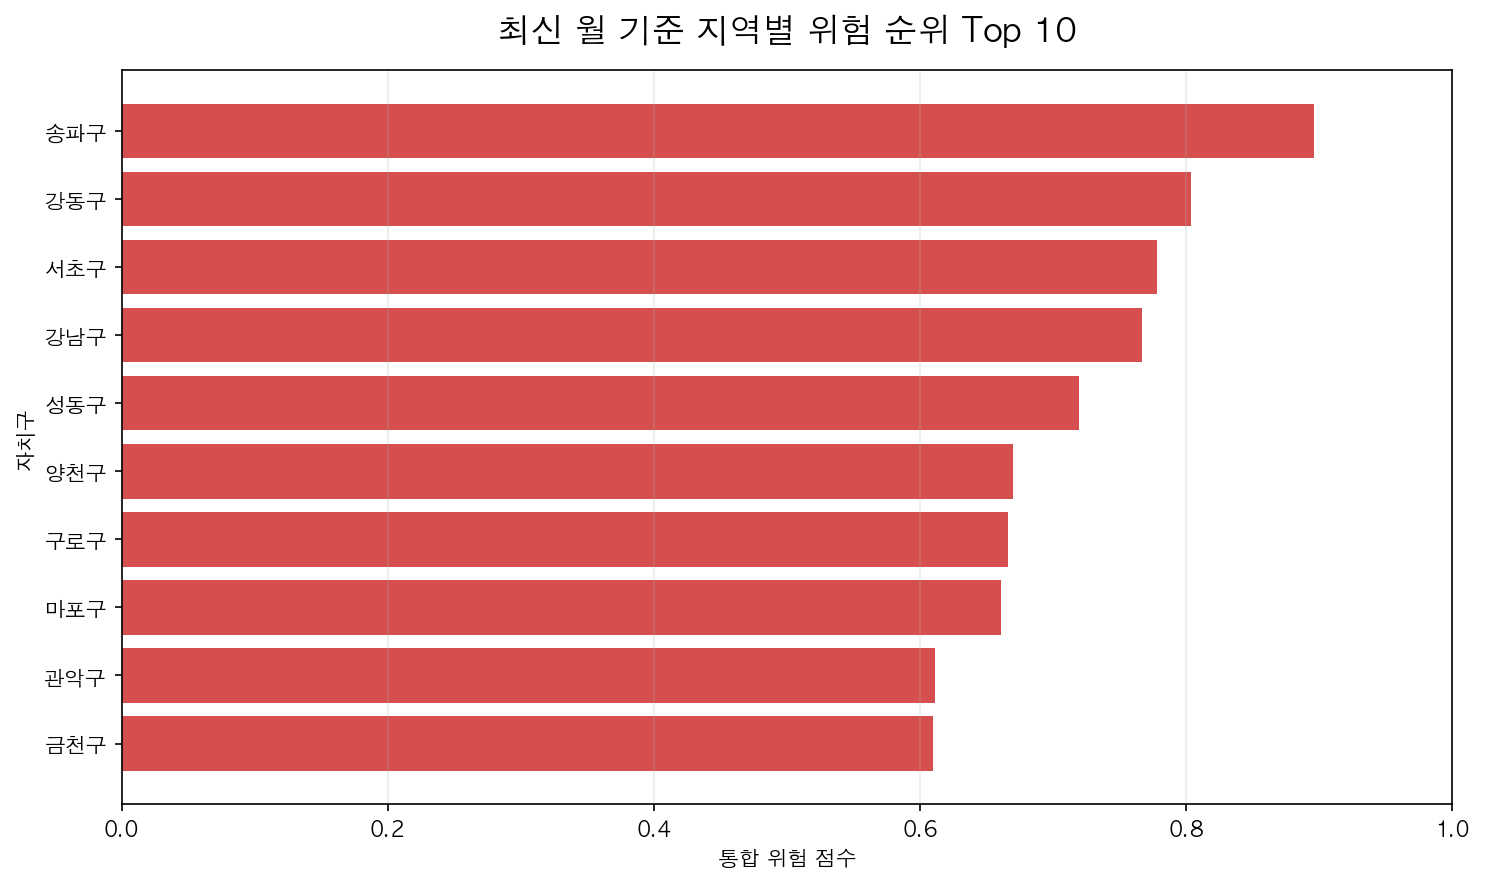

In [5]:
top10 = ranking.sort_values("rank").head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10["gu"][::-1], top10["total_risk_score"][::-1], color="#D64F4F")
ax.set_title("최신 월 기준 지역별 위험 순위 Top 10", fontsize=16, pad=14)
ax.set_xlabel("통합 위험 점수")
ax.set_ylabel("자치구")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.25)
save_fig("latest_top10_region_risk_score.png")


**해석**
- 최신 월 기준 통합 위험 점수는 송파구, 강동구, 서초구, 강남구, 성동구 순으로 높게 나타납니다.
- 이 지역들은 매매가 상승률, 매매-전세 괴리율, 전세가율, 월세화 흐름 등 여러 위험 지표가 함께 반영된 결과로 상위권에 위치합니다.
- 발표에서는 이 그래프를 핵심 결과로 사용해 “현재 시점에서 우선적으로 확인해야 할 지역은 어디인가?”라는 질문에 답할 수 있습니다.


## 4. 최신 월 기준 위험 등급 분포


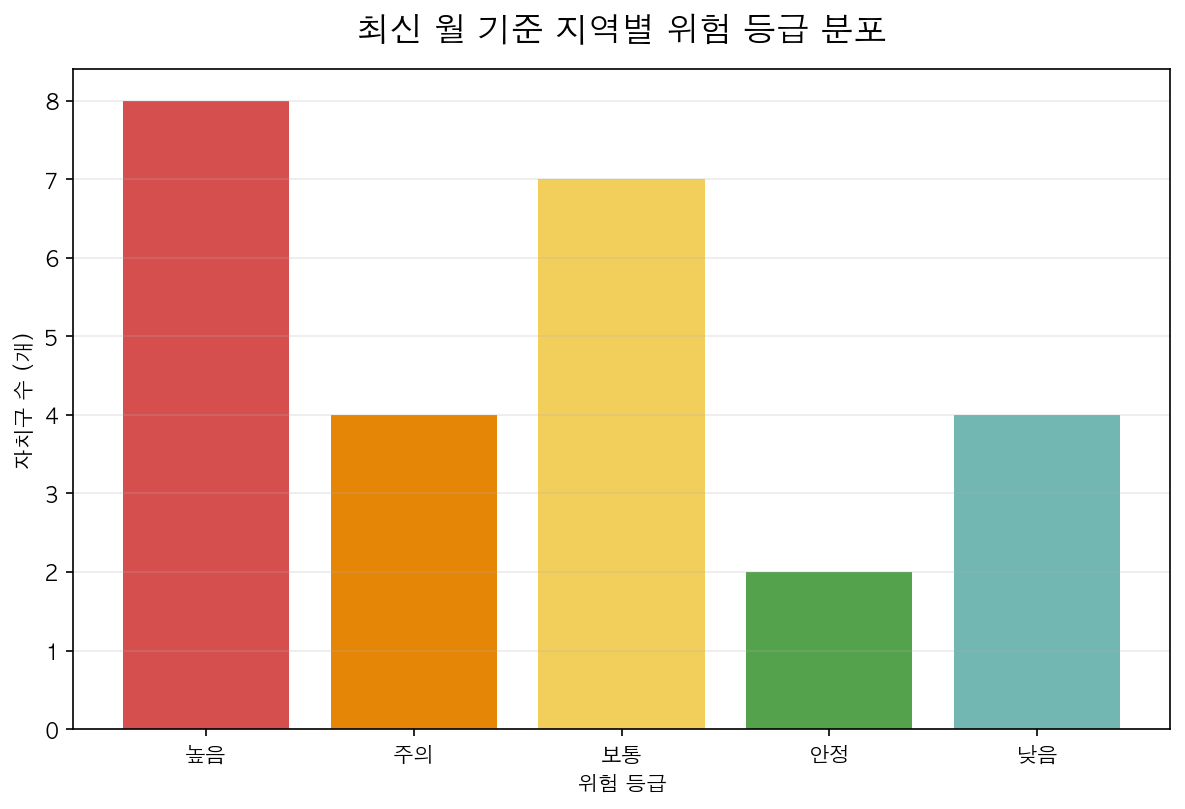

In [6]:
grade_order = ["높음", "주의", "보통", "안정", "낮음"]
grade_counts = ranking["risk_grade"].value_counts().reindex(grade_order).dropna()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(grade_counts.index, grade_counts.values, color=["#D64F4F", "#E58606", "#F2CF5B", "#54A24B", "#72B7B2"][: len(grade_counts)])
ax.set_title("최신 월 기준 지역별 위험 등급 분포", fontsize=16, pad=14)
ax.set_xlabel("위험 등급")
ax.set_ylabel("자치구 수 (개)")
comma_axis(ax)
ax.grid(axis="y", alpha=0.25)
save_fig("latest_risk_grade_distribution.png")


**해석**
- 최신 월 기준으로 서울 25개 자치구는 `높음`, `주의`, `보통` 등 여러 위험 등급으로 나뉩니다.
- 특정 등급에 모든 지역이 몰리지 않고 등급이 나뉘기 때문에, 모델 결과가 지역별 위험 수준 차이를 구분하고 있음을 보여줍니다.
- 이 그래프는 Top 10 순위 그래프를 보완하며, 서울 전체 지역의 위험 분포를 요약하는 보조 그래프로 활용할 수 있습니다.


## 5. 분류 모델 성능 비교


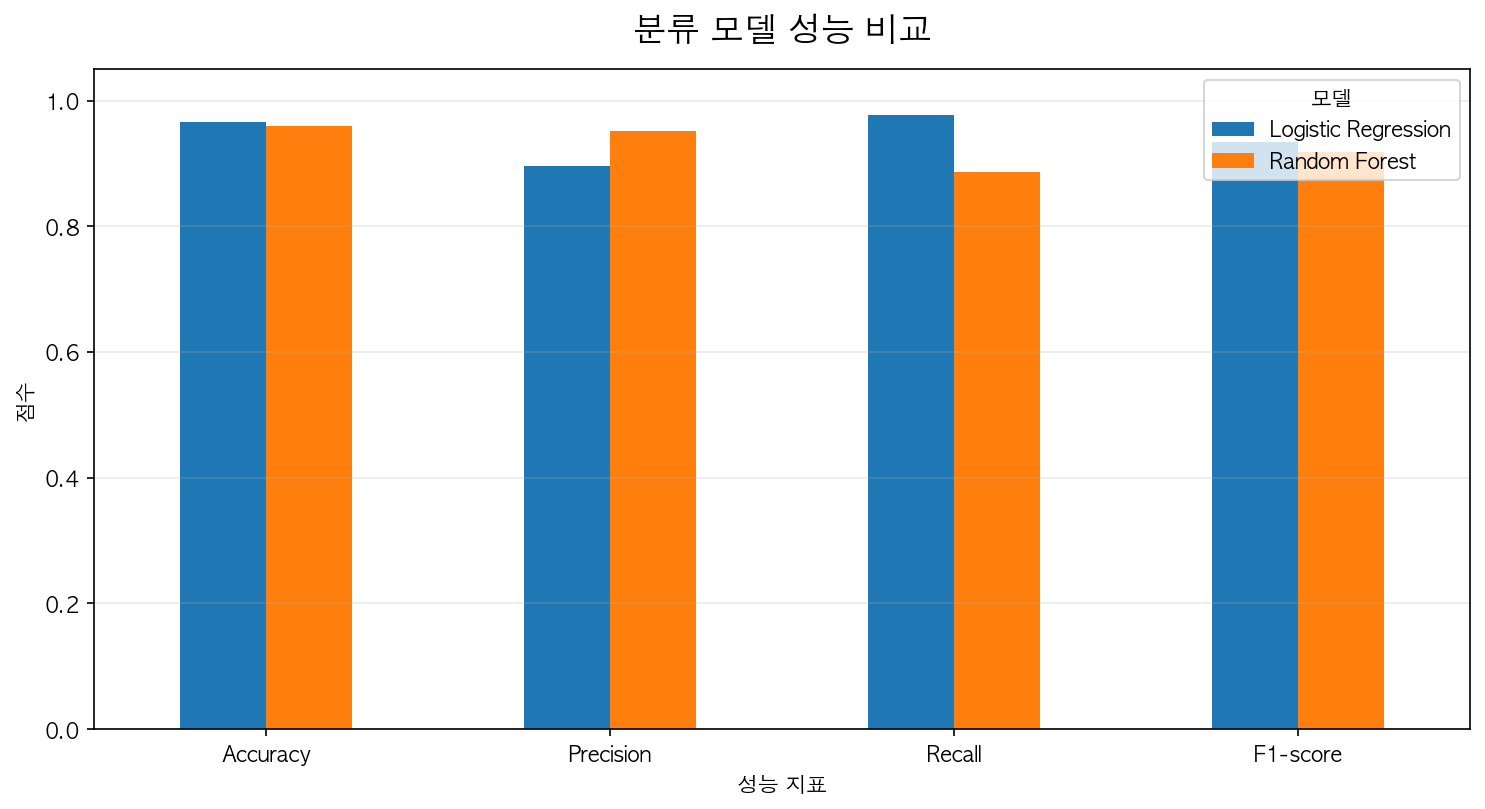

In [7]:
metrics = ["accuracy", "precision", "recall", "f1_score"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-score"]

fig, ax = plt.subplots(figsize=(10, 5.5))
comparison.set_index("model")[metrics].T.plot(kind="bar", ax=ax)
ax.set_title("분류 모델 성능 비교", fontsize=16, pad=14)
ax.set_xlabel("성능 지표")
ax.set_ylabel("점수")
ax.set_xticklabels(metric_labels, rotation=0)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="모델")
save_fig("model_comparison_metrics.png")


**해석**
- F1-score 기준으로는 Logistic Regression이 Random Forest보다 약간 높게 나타납니다.
- Random Forest는 precision이 높아 위험으로 예측한 지역의 정확도가 상대적으로 높고, Logistic Regression은 recall이 높아 실제 위험 지역을 놓치지 않는 성향이 강합니다.
- 부동산 위험 탐지에서는 위험 지역을 놓치는 것이 더 큰 문제가 될 수 있으므로, 발표에서는 Logistic Regression의 높은 recall과 F1-score를 중심으로 설명할 수 있습니다.


## 6. Random Forest 변수 중요도


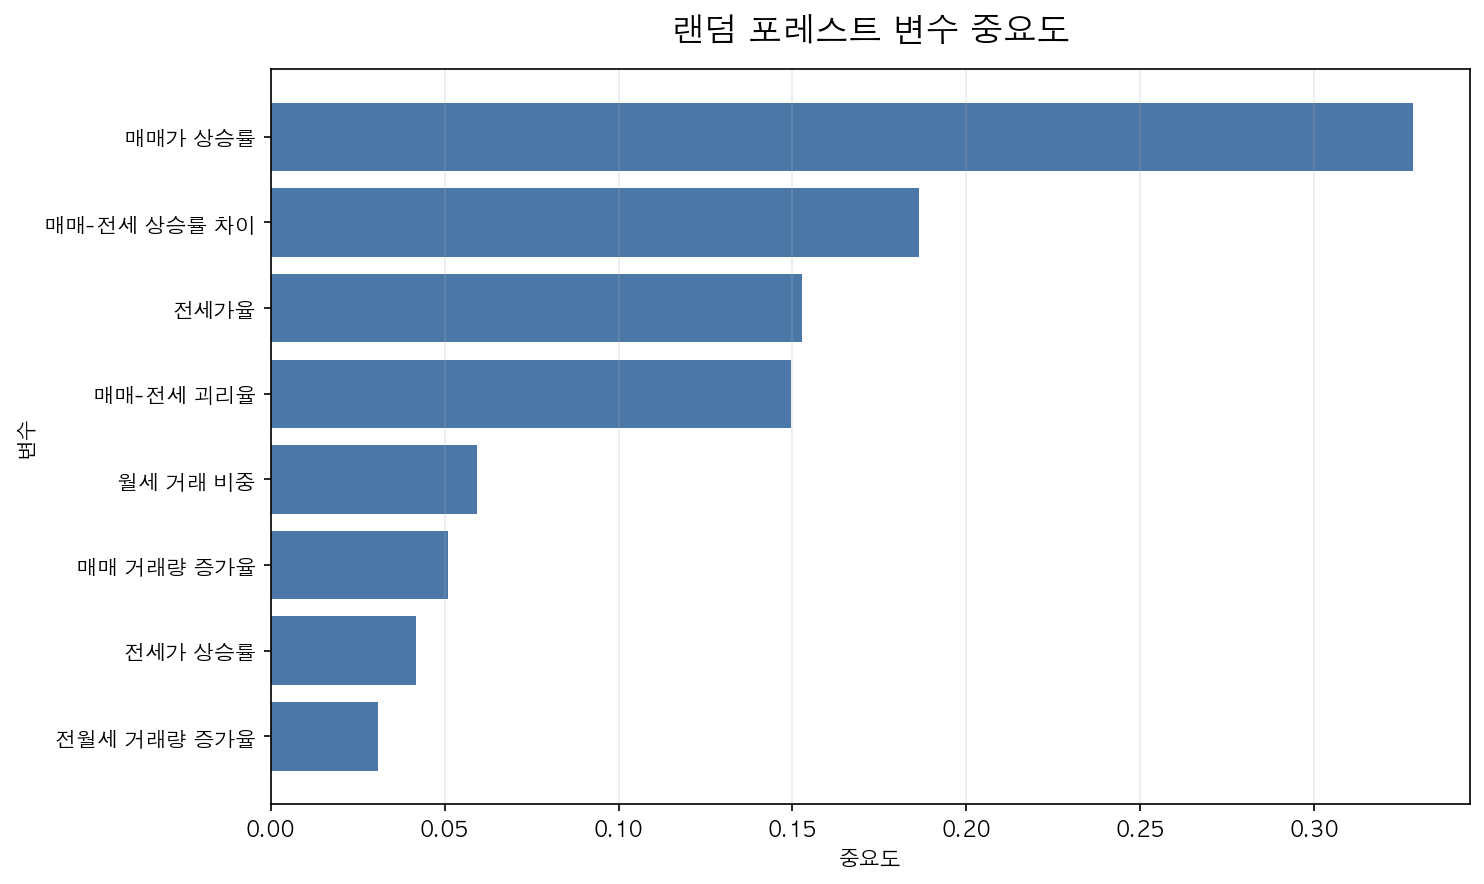

In [8]:
feature_labels = {
    "sale_growth_1m": "매매가 상승률",
    "growth_gap_1m": "매매-전세 상승률 차이",
    "jeonse_rate": "전세가율",
    "gap_rate": "매매-전세 괴리율",
    "monthly_ratio": "월세 거래 비중",
    "sale_volume_growth_1m": "매매 거래량 증가율",
    "jeonse_growth_1m": "전세가 상승률",
    "rent_volume_growth_1m": "전월세 거래량 증가율",
}
importance_plot = importance.sort_values("importance").copy()
importance_plot["feature_label"] = importance_plot["feature"].map(feature_labels).fillna(importance_plot["feature"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_plot["feature_label"], importance_plot["importance"], color="#4C78A8")
ax.set_title("랜덤 포레스트 변수 중요도", fontsize=16, pad=14)
ax.set_xlabel("중요도")
ax.set_ylabel("변수")
ax.grid(axis="x", alpha=0.25)
save_fig("feature_importance.png")


**해석**
- 위험 지역 분류에는 `매매가 상승률`이 가장 크게 작용한 것으로 나타납니다.
- `매매-전세 상승률 차이`, `전세가율`, `매매-전세 괴리율`도 상위 변수로 나타나며, 매매가격이 전세가격이나 실수요 흐름과 얼마나 괴리되는지가 중요한 판단 기준임을 보여줍니다.
- 이는 발표 흐름에서 제시한 실거주자 위험과 투자자 위험의 핵심 논리, 즉 “가격 상승이 실수요로 뒷받침되는가?”라는 질문과 직접 연결됩니다.


## 발표용 핵심 그래프 선별

발표에는 아래 4개 그래프를 우선 사용하는 것을 추천합니다.

1. `latest_top10_region_risk_score.png`: 최신 월 기준으로 어느 지역의 위험 점수가 높은지 가장 직접적으로 보여줍니다.
2. `kmeans_avg_risk_score.png`: K-Means 군집별 위험 수준 차이를 설명하기 좋으며, 군집 결과 시각화의 핵심 그래프로 사용할 수 있습니다.
3. `feature_importance.png`: 모델이 어떤 변수를 중요하게 판단했는지 보여주며, 위험 지수 설계 논리와 모델 결과를 연결할 수 있습니다.
4. `model_comparison_metrics.png`: Logistic Regression과 Random Forest의 성능을 비교해 B팀 모델 결과의 신뢰도를 요약할 수 있습니다.

보조 그래프로는 `latest_risk_grade_distribution.png`, `kmeans_cluster_sample_count.png`를 사용하면 좋습니다. 두 그래프는 각각 전체 지역의 위험 등급 분포와 K-Means 군집별 표본 분포를 보완적으로 설명합니다.
